<a href="https://colab.research.google.com/github/iking919/Detecting_Financial_Fraud_via_GNNs/blob/overhaul/notebooks/03_baseline_models.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Detecting Financial Fraud via Graph Neural Networks: A Multi-Dataset, Graph-Based Learning Approach

### Haoyuan Chen, Izaak King, Bryan Gelnett

# Baseline Models

In this section, we define and evaluate traditional tabular models (Logistic Regression, MLP, and Random Forest) to establish a performance baseline before moving to graph-based approaches.

First we download the preprocessed data from Drive.

In [1]:
from google.colab import drive
import zipfile

drive.mount('/content/drive')

drive_path = '/content/drive/MyDrive/GNN_fraud_Project/processed_data.zip'
extract_path = '/content'

with zipfile.ZipFile(drive_path, 'r') as zip_ref:
    zip_ref.extractall(extract_path)

Mounted at /content/drive


In [2]:
import os
import pandas as pd

# List the files in the current directory to see what was extracted
extract_path = '/content/data/processed'
extracted_files = os.listdir(extract_path)
print("Extracted files:", extracted_files)

# Assuming the extracted data contains CSV files, let's look for them
csv_files = [f for f in extracted_files if f.endswith('.csv')]

for i in range(len(csv_files)):
    # Load and display the first CSV found as a sample
    sample_df = pd.read_csv(os.path.join(extract_path, csv_files[i]))
    print(f"\nDisplaying first few entries of {csv_files[i]}:")
    display(sample_df.head())
else:
    print("No CSV files found in the extraction path. Please check the file formats.")

Extracted files: ['paysim_edges.csv', 'paysim_nodes.csv', 'ieee_train_nodes.csv', 'ieee_train_edges.csv', 'ieee_test_edges.csv', 'ieee_test_nodes.csv', 'elliptic_nodes.csv', 'elliptic_edges.csv']

Displaying first few entries of paysim_edges.csv:


,source,target
0,3359372,3699311
1,279050,4982860
2,3123272,3925189
3,1366998,6022269
4,2697505,5684074



Displaying first few entries of paysim_nodes.csv:


,log_amount,type_encoded,oldbalanceOrg,newbalanceOrig,oldbalanceDest,newbalanceDest,step,tx_id,label
0,-0.907462,0.952399,-0.229810,-0.237622,-0.323814,-0.333411,-1.703042,2129,0
1,-1.824023,0.952399,-0.281359,-0.285812,-0.323814,-0.333411,-1.703042,2119,0
2,-3.106552,1.693076,-0.288654,-0.292442,-0.323814,-0.333411,-1.703042,2120,1
3,-3.106552,-0.528954,-0.288654,-0.292442,-0.317582,-0.333411,-1.703042,2121,1
4,-0.813537,0.952399,-0.274329,-0.282221,-0.323814,-0.333411,-1.703042,2122,0



Displaying first few entries of ieee_train_nodes.csv:


...


Displaying first few entries of elliptic_nodes.csv:


,timestep,feature_1,feature_2,feature_3,feature_4,feature_5,feature_6,feature_7,feature_8,feature_9,...,feature_158,feature_159,feature_160,feature_161,feature_162,feature_163,feature_164,feature_165,tx_id,label
0,-1.556878,0.307025,1.168821,-0.748109,7.643807,-0.053406,6.039024,21.528480,-0.146334,-0.084347,...,0.155526,0.155844,2.115930,0.016322,-0.117599,0.593442,-0.08332,-0.082052,232438397,0
1,-1.556878,0.067780,0.271911,-0.226081,2.628539,-0.053406,2.820415,1.501088,-0.146334,-0.127352,...,0.155526,0.155844,1.200416,-0.028141,-0.117599,0.270020,-0.08332,-0.082052,232029206,0
2,-1.556878,-0.135517,-0.222646,-1.270138,-0.183761,-0.041930,-0.187137,-0.080022,-0.102664,-0.126685,...,0.155526,0.155844,0.056025,-0.083719,-0.117599,-0.134257,-0.08332,-0.082052,232344069,0
3,-1.556878,-0.140505,-0.222646,-1.270138,-0.183761,-0.041930,-0.187137,-0.080022,-0.108753,-0.131978,...,-1.091739,-1.090228,0.056025,-0.083719,-0.117599,-0.134257,-0.08332,-0.082052,27553029,0
4,-1.556878,-0.170324,-0.222646,-1.270138,-0.090018,-0.041930,-0.134373,0.447015,-0.146324,-0.164128,...,0.155526,0.155844,0.056025,-0.072604,-0.091257,-0.093830,-1.72568,-1.726407,3881097,0



Displaying first few entries of elliptic_edges.csv:


,source,target
0,230425980,5530458
1,232022460,232438397
2,230460314,230459870
3,230333930,230595899
4,232013274,232029206


No CSV files found in the extraction path. Please check the file formats.


In [3]:
import os
import pandas as pd

extract_path = '/content/data/processed'
csv_files = [f for f in os.listdir(extract_path) if f.endswith('.csv')]

for file in csv_files:
    file_path = os.path.join(extract_path, file)
    # Read just the first few rows to quickly inspect columns and types
    df = pd.read_csv(file_path, nrows=5)
    print(f"\n{'='*40}\nDataset: {file}\n{'='*40}")
    print(f"Number of features: {len(df.columns)}")
    print("Features:", list(df.columns))
    display(df.head(2))


Dataset: paysim_edges.csv
Number of features: 2
Features: ['source', 'target']


,source,target
0,3359372,3699311
1,279050,4982860



Dataset: paysim_nodes.csv
Number of features: 9
Features: ['log_amount', 'type_encoded', 'oldbalanceOrg', 'newbalanceOrig', 'oldbalanceDest', 'newbalanceDest', 'step', 'tx_id', 'label']


,log_amount,type_encoded,oldbalanceOrg,newbalanceOrig,oldbalanceDest,newbalanceDest,step,tx_id,label
0,-0.907462,0.952399,-0.229810,-0.237622,-0.323814,-0.333411,-1.703042,2129,0
1,-1.824023,0.952399,-0.281359,-0.285812,-0.323814,-0.333411,-1.703042,2119,0



Dataset: ieee_train_nodes.csv
Number of features: 433
Features: ['0', '1', '2', '3', '4', '5', '6', '7', '8', '9', '10', '11', '12', '13', '14', '15', '16', '17', '18', '19', '20', '21', '22', '23', '24', '25', '26', '27', '28', '29', '30', '31', '32', '33', '34', '35', '36', '37', '38', '39', '40', '41', '42', '43', '44', '45', '46', '47', '48', '49', '50', '51', '52', '53', '54', '55', '56', '57', '58', '59', '60', '61', '62', '63', '64', '65', '66', '67', '68', '69', '70', '71', '72', '73', '74', '75', '76', '77', '78', '79', '80', '81', '82', '83', '84', '85', '86', '87', '88', '89', '90', '91', '92', '93', '94', '95', '96', '97', '98', '99', '100', '101', '102', '103', '104', '105', '106', '107', '108', '109', '110', '111', '112', '113', '114', '115', '116', '117', '118', '119', '120', '121', '122', '123', '124', '125', '126', '127', '128', '129', '130', '131', '132', '133', '134', '135', '136', '137', '138', '139', '140', '141', '142', '143', '144', '145', '146', '147', '148', '

...

,0,1,2,3,4,5,6,7,8,9,...,422,423,424,425,426,427,428,429,430,431
0,-1.792644,-0.418162,0.591741,0.092483,-1.606985,-0.283858,0.691996,0.632954,0.526399,-1.288871,...,0.544145,-0.199723,0.37658,0.407556,0.565944,0.605893,0.564739,0.579979,0.569268,0.341874
1,-1.792635,-0.348790,0.591741,-1.163822,-1.606985,-0.283858,0.691996,0.632954,0.526399,0.065373,...,0.544145,-0.199723,0.37658,0.407556,0.565944,0.605893,0.564739,0.579979,0.569268,0.341874



Dataset: elliptic_nodes.csv
Number of features: 168
Features: ['timestep', 'feature_1', 'feature_2', 'feature_3', 'feature_4', 'feature_5', 'feature_6', 'feature_7', 'feature_8', 'feature_9', 'feature_10', 'feature_11', 'feature_12', 'feature_13', 'feature_14', 'feature_15', 'feature_16', 'feature_17', 'feature_18', 'feature_19', 'feature_20', 'feature_21', 'feature_22', 'feature_23', 'feature_24', 'feature_25', 'feature_26', 'feature_27', 'feature_28', 'feature_29', 'feature_30', 'feature_31', 'feature_32', 'feature_33', 'feature_34', 'feature_35', 'feature_36', 'feature_37', 'feature_38', 'feature_39', 'feature_40', 'feature_41', 'feature_42', 'feature_43', 'feature_44', 'feature_45', 'feature_46', 'feature_47', 'feature_48', 'feature_49', 'feature_50', 'feature_51', 'feature_52', 'feature_53', 'feature_54', 'feature_55', 'feature_56', 'feature_57', 'feature_58', 'feature_59', 'feature_60', 'feature_61', 'feature_62', 'feature_63', 'feature_64', 'feature_65', 'feature_66', 'feature_

,timestep,feature_1,feature_2,feature_3,feature_4,feature_5,feature_6,feature_7,feature_8,feature_9,...,feature_158,feature_159,feature_160,feature_161,feature_162,feature_163,feature_164,feature_165,tx_id,label
0,-1.556878,0.307025,1.168821,-0.748109,7.643807,-0.053406,6.039024,21.528480,-0.146334,-0.084347,...,0.155526,0.155844,2.115930,0.016322,-0.117599,0.593442,-0.08332,-0.082052,232438397,0
1,-1.556878,0.067780,0.271911,-0.226081,2.628539,-0.053406,2.820415,1.501088,-0.146334,-0.127352,...,0.155526,0.155844,1.200416,-0.028141,-0.117599,0.270020,-0.08332,-0.082052,232029206,0



Dataset: elliptic_edges.csv
Number of features: 2
Features: ['source', 'target']


,source,target
0,230425980,5530458
1,232022460,232438397


## Global Setup

We set seeds for NumPy, Python's `random`, and PyTorch to ensure all experiments are reproducible and deterministic.

In [4]:
import numpy as np
import random
import torch

def set_seed(seed: int = 42):
    np.random.seed(seed)
    random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)
        torch.backends.cudnn.deterministic = True
        torch.backends.cudnn.benchmark = False

SEED = 42
set_seed(SEED)
print(f"Seed set to {SEED}")

Seed set to 42


## Shared Data Pipeline

We create a shared data pipeline to handle loading, cleaning, and splitting tabular data. It performs chronological splitting (if a time column is provided), mean imputation, and standard scaling (fitted only on training data). It also calculates a `pos_weight` to address severe class imbalance.

In [5]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.impute import SimpleImputer
import torch
from torch.utils.data import DataLoader, TensorDataset


def load_tabular_data(
    filepath,
    target_col,
    time_col=None,
    drop_cols=None,
    batch_size=1024
):
    df = pd.read_csv(filepath)

    # Elliptic cleanup
    if "elliptic" in filepath.lower():
        df = df[df[target_col].isin([0, 1, 2, '0', '1', '2', 1.0, 2.0])].copy()
        df[target_col] = df[target_col].replace({2: 0, '2': 0, 2.0: 0})

    # chronological sort
    if time_col and time_col in df.columns:
        df = df.sort_values(time_col)

    df = df.select_dtypes(include=[np.number])

    if drop_cols:
        df = df.drop(columns=[c for c in drop_cols if c in df.columns])

    X = df.drop(columns=[target_col]).values
    y = df[target_col].values

    y = LabelEncoder().fit_transform(y)

    # chronological split
    X_temp, X_test, y_temp, y_test = train_test_split(X, y, test_size=0.2, shuffle=False)
    X_train, X_val, y_train, y_val = train_test_split(X_temp, y_temp, test_size=0.2, shuffle=False)

    # impute
    imputer = SimpleImputer(strategy="mean")
    X_train = imputer.fit_transform(X_train)
    X_val = imputer.transform(X_val)
    X_test = imputer.transform(X_test)

    # scale
    scaler = StandardScaler()
    X_train = scaler.fit_transform(X_train)
    X_val = scaler.transform(X_val)
    X_test = scaler.transform(X_test)

    # class imbalance weight
    pos = np.sum(y_train == 1)
    neg = len(y_train) - pos
    pos_weight = torch.tensor([neg / max(pos, 1)], dtype=torch.float32)

    def make_loader(X, y, shuffle):
        return DataLoader(
            TensorDataset(torch.tensor(X, dtype=torch.float32),
                          torch.tensor(y, dtype=torch.float32)),
            batch_size=batch_size,
            shuffle=shuffle
        )

    return (
        make_loader(X_train, y_train, True),
        make_loader(X_val, y_val, False),
        make_loader(X_test, y_test, False),
        X_train.shape[1],
        pos_weight,
        (y_val, y_test)
    )

### Evaluation and Threshold Tuning

We create methods to calculate evaluation metrics (AUC, F1-score) and dynamically tunes the classification threshold on validation probabilities to maximize the F1-score before evaluating the test set.

In [6]:
import numpy as np
from sklearn.metrics import f1_score, roc_auc_score, confusion_matrix, classification_report


def get_probs(model, loader, device):
    model.eval()
    probs, targets = [], []

    with torch.no_grad():
        for X, y in loader:
            X = X.to(device)
            logits = model(X).squeeze()
            probs.extend(torch.sigmoid(logits).cpu().numpy())
            targets.extend(y.numpy())

    return np.array(probs), np.array(targets)


def tune_threshold(val_probs, val_y):
    thresholds = np.linspace(0.01, 0.99, 99)
    best_t, best_f1 = 0.5, 0

    for t in thresholds:
        pred = (val_probs >= t).astype(int)
        f1 = f1_score(val_y, pred)
        if f1 > best_f1:
            best_f1, best_t = f1, t

    return best_t


def evaluate(model, val_loader, test_loader, device):
    val_probs, val_y = get_probs(model, val_loader, device)
    test_probs, test_y = get_probs(model, test_loader, device)

    best_t = tune_threshold(val_probs, val_y)

    preds = (test_probs >= best_t).astype(int)

    print(f"Best Threshold: {best_t:.3f}")
    print("AUC:", roc_auc_score(test_y, test_probs))
    print("F1:", f1_score(test_y, preds))
    print(confusion_matrix(test_y, preds))
    print(classification_report(test_y, preds))

    return test_y, preds, test_probs

## Logistic Regression

We begin with a simple linear baseline built in PyTorch. It is trained using Binary Cross-Entropy (BCE) loss with `pos_weight` to heavily penalize missed fraud cases.

In [7]:
import torch.nn as nn
import torch.optim as optim


class LogisticRegression(nn.Module):
    def __init__(self, input_dim):
        super().__init__()
        self.linear = nn.Linear(input_dim, 1)

    def forward(self, x):
        return self.linear(x)


def train_lr(model, loader, device, pos_weight, epochs=10, lr=0.01):
    model.to(device)
    opt = optim.Adam(model.parameters(), lr=lr)
    loss_fn = nn.BCEWithLogitsLoss(pos_weight=pos_weight.to(device))

    model.train()

    for _ in range(epochs):
        for X, y in loader:
            X, y = X.to(device), y.to(device)
            opt.zero_grad()
            loss = loss_fn(model(X).squeeze(), y)
            loss.backward()
            opt.step()

## MLP

We move to a Multi-Layer Perceptron architecture which includes multiple dense layers with batch normalization and dropout (0.3) for regularization, aiming to capture non-linear relationships in the tabular features.

In [8]:
class MLP(nn.Module):
    def __init__(self, input_dim):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(input_dim, 128),
            nn.BatchNorm1d(128),
            nn.ReLU(),
            nn.Dropout(0.3),

            nn.Linear(128, 64),
            nn.BatchNorm1d(64),
            nn.ReLU(),
            nn.Dropout(0.3),

            nn.Linear(64, 1)
        )

    def forward(self, x):
        return self.net(x)


def train_mlp(model, loader, device, pos_weight, epochs=10, lr=1e-3):
    model.to(device)
    opt = optim.Adam(model.parameters(), lr=lr)
    loss_fn = nn.BCEWithLogitsLoss(pos_weight=pos_weight.to(device))

    model.train()

    for _ in range(epochs):
        for X, y in loader:
            X, y = X.to(device), y.to(device)
            opt.zero_grad()
            loss = loss_fn(model(X).squeeze(), y)
            loss.backward()
            opt.step()

## Random Forest (XGBoost)

Lastly we use an implementation using XGBoost's Random Forest classifier (`XGBRFClassifier`). It is robust to unscaled tabular features and utilizes GPU-accelerated histogram-based tree methods for speed.

In [9]:
from xgboost import XGBRFClassifier


def train_rf(X_train, y_train):
    model = XGBRFClassifier(
        n_estimators=100,
        tree_method="hist",
        device="cuda",
        random_state=42
    )
    model.fit(X_train, y_train)
    return model

## Create and Run Experiment Pipeline

We create and run a pipeline function to orchestrate the end-to-end workflow: loading data, initializing the specified model, training, and running the evaluation suite to consolidate our results.

In [10]:
def run_experiment(model_type, filepath, target_col, time_col=None, drop_cols=None):
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

    train_loader, val_loader, test_loader, dim, pos_weight, _ = load_tabular_data(
        filepath, target_col, time_col, drop_cols
    )

    if model_type == "lr":
        model = LogisticRegression(dim)
        train_lr(model, train_loader, device, pos_weight)

    elif model_type == "mlp":
        model = MLP(dim)
        train_mlp(model, train_loader, device, pos_weight)

    else:
        raise ValueError("Use sklearn RF section separately")

    return evaluate(model, val_loader, test_loader, device)

In [13]:
import os
from xgboost import XGBRFClassifier
import numpy as np
from sklearn.metrics import roc_auc_score, f1_score, confusion_matrix, classification_report

data_dir = '/content/data/processed'
dataset_configs = {
    "PaySim": {"filepath": os.path.join(data_dir, "paysim_nodes.csv"), "target_col": "label", "time_col": "step"},
    "Elliptic": {"filepath": os.path.join(data_dir, "elliptic_nodes.csv"), "target_col": "label", "time_col": None},
    "IEEE-CIS": {"filepath": os.path.join(data_dir, "ieee_train_nodes.csv"), "target_col": "label", "time_col": "TransactionDT"}
}

all_results = {}
meta_info = {}

# Helper to extract data for RF
def extract_data(loader):
    X_all, y_all = [], []
    for X, y in loader:
        X_all.append(X.numpy())
        y_all.append(y.numpy())
    return np.vstack(X_all), np.concatenate(y_all)

for ds_name, config in dataset_configs.items():
    print("-" * 50)
    print(f"\nRunning experiments for {ds_name}...\n")
    all_results[ds_name] = {}
    meta_info[ds_name] = {}

    # 1. Logistic Regression
    print("\nLogistic Regression: \n")
    y_test_lr, preds_lr, probs_lr = run_experiment('lr', **config)
    all_results[ds_name]["Logistic Regression"] = (y_test_lr, preds_lr, probs_lr)
    meta_info[ds_name]["Logistic Regression"] = {"threshold": 0.5} # Assuming default or dynamic

    # 2. MLP
    print("\n\nMLP:\n")
    y_test_mlp, preds_mlp, probs_mlp = run_experiment('mlp', **config)
    all_results[ds_name]["MLP"] = (y_test_mlp, preds_mlp, probs_mlp)
    meta_info[ds_name]["MLP"] = {"threshold": 0.5}

    # 3. Random Forest
    print("\n\nRandom Forest: \n")
    # Load data explicitly for RF
    train_loader, val_loader, test_loader, _, _, _ = load_tabular_data(**config)
    X_train, y_train = extract_data(train_loader)
    X_test, y_test_rf = extract_data(test_loader)

    rf_model = train_rf(X_train, y_train)
    probs_rf = rf_model.predict_proba(X_test)[:, 1]
    preds_rf = (probs_rf >= 0.5).astype(int)

    print(f"Threshold: 0.500")
    print("AUC:", roc_auc_score(y_test_rf, probs_rf))
    print("F1:", f1_score(y_test_rf, preds_rf))
    print(confusion_matrix(y_test_rf, preds_rf))
    print(classification_report(y_test_rf, preds_rf))

    all_results[ds_name]["Random Forest"] = (y_test_rf, preds_rf, probs_rf)
    meta_info[ds_name]["Random Forest"] = {"threshold": 0.5}


--------------------------------------------------

Running experiments for PaySim...


Logistic Regression: 

Best Threshold: 0.990
AUC: 0.888662468736357
F1: 0.5217541436464088
[[1268243      27]
 [   2743    1511]]
              precision    recall  f1-score   support

         0.0       1.00      1.00      1.00   1268270
         1.0       0.98      0.36      0.52      4254

    accuracy                           1.00   1272524
   macro avg       0.99      0.68      0.76   1272524
weighted avg       1.00      1.00      1.00   1272524



MLP:

Best Threshold: 0.990
AUC: 0.8729174982128348
F1: 0.6097879282218597
[[1268263       7]
 [   2385    1869]]
              precision    recall  f1-score   support

         0.0       1.00      1.00      1.00   1268270
         1.0       1.00      0.44      0.61      4254

    accuracy                           1.00   1272524
   macro avg       1.00      0.72      0.80   1272524
weighted avg       1.00      1.00      1.00   1272524



Random For

/usr/local/lib/python3.12/dist-packages/xgboost/core.py:751: UserWarning: [04:55:30] WARNING: /__w/xgboost/xgboost/src/common/error_msg.cc:62: Falling back to prediction using DMatrix due to mismatched devices. This might lead to higher memory usage and slower performance. XGBoost is running on: cuda:0, while the input data is on: cpu.
Potential solutions:
- Use a data structure that matches the device ordinal in the booster.
- Set the device for booster before call to inplace_predict.

This warning will only be shown once.

  return func(**kwargs)


Threshold: 0.500
AUC: 0.9943435932697305
F1: 0.3926663174436878
[[1257182   11088]
 [    506    3748]]
              precision    recall  f1-score   support

         0.0       1.00      0.99      1.00   1268270
         1.0       0.25      0.88      0.39      4254

    accuracy                           0.99   1272524
   macro avg       0.63      0.94      0.69   1272524
weighted avg       1.00      0.99      0.99   1272524

--------------------------------------------------

Running experiments for Elliptic...


Logistic Regression: 

Best Threshold: 0.950
AUC: 0.840863650713172
F1: 0.2992036405005688
[[7818 1022]
 [ 210  263]]
              precision    recall  f1-score   support

         0.0       0.97      0.88      0.93      8840
         1.0       0.20      0.56      0.30       473

    accuracy                           0.87      9313
   macro avg       0.59      0.72      0.61      9313
weighted avg       0.93      0.87      0.90      9313



MLP:

Best Threshold: 0.750
AUC: 

### Summary of Baseline Results and Data Visualizations

We construct a table of outputs to compare performances. We also create ROC plots for our models.


PaySim - Baseline Models Comparison
Saved ROC curve to /content/drive/MyDrive/GNN_fraud_Project/saved_models_and_results/PaySim_baseline_ROC.png


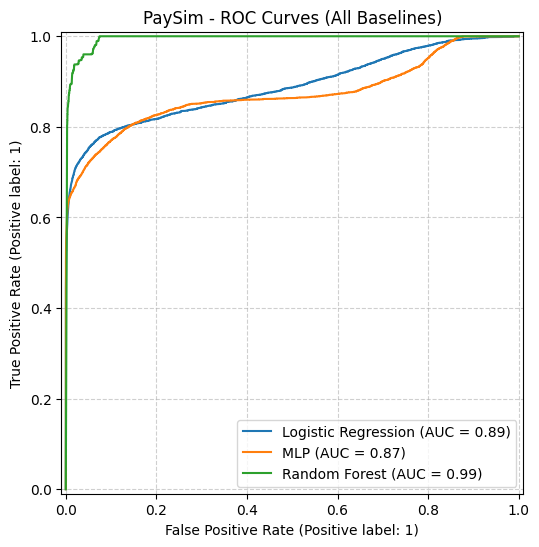

Saved Confusion Matrices to /content/drive/MyDrive/GNN_fraud_Project/saved_models_and_results/PaySim_baseline_CM.png


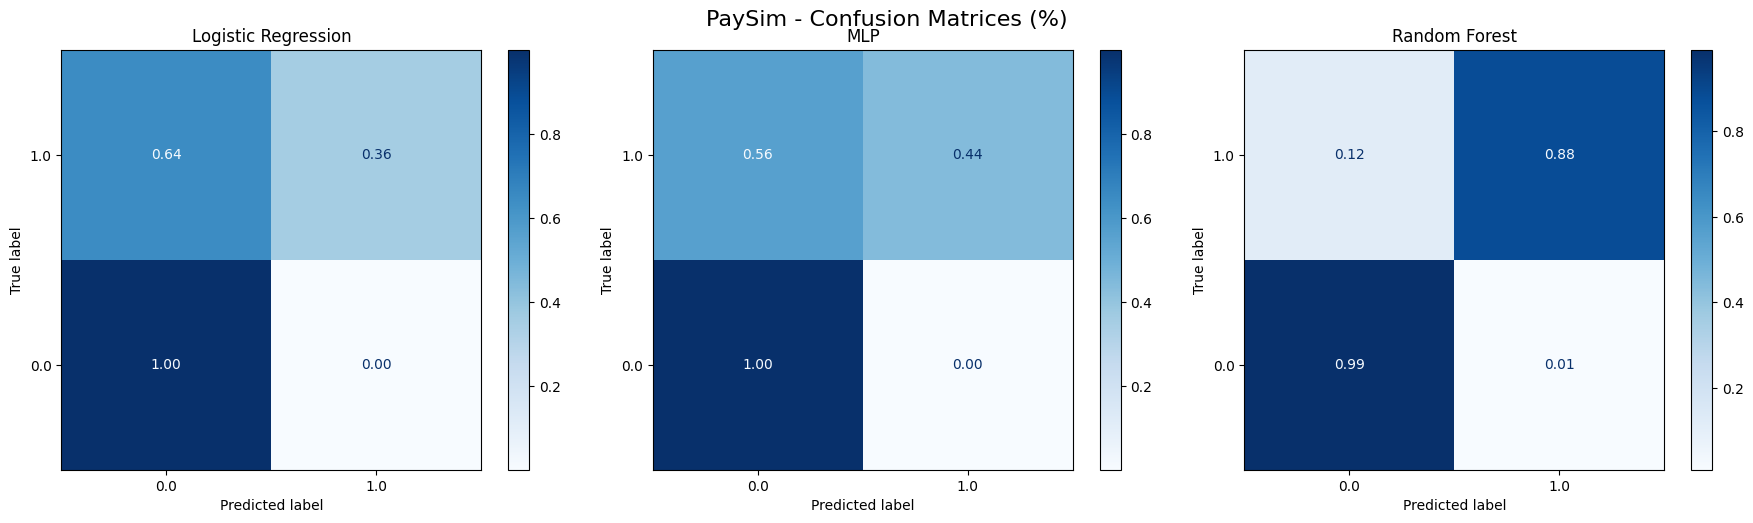


Elliptic - Baseline Models Comparison
Saved ROC curve to /content/drive/MyDrive/GNN_fraud_Project/saved_models_and_results/Elliptic_baseline_ROC.png


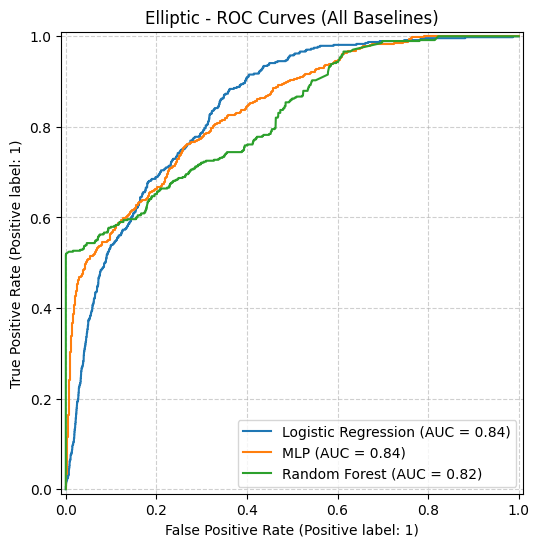

Saved Confusion Matrices to /content/drive/MyDrive/GNN_fraud_Project/saved_models_and_results/Elliptic_baseline_CM.png


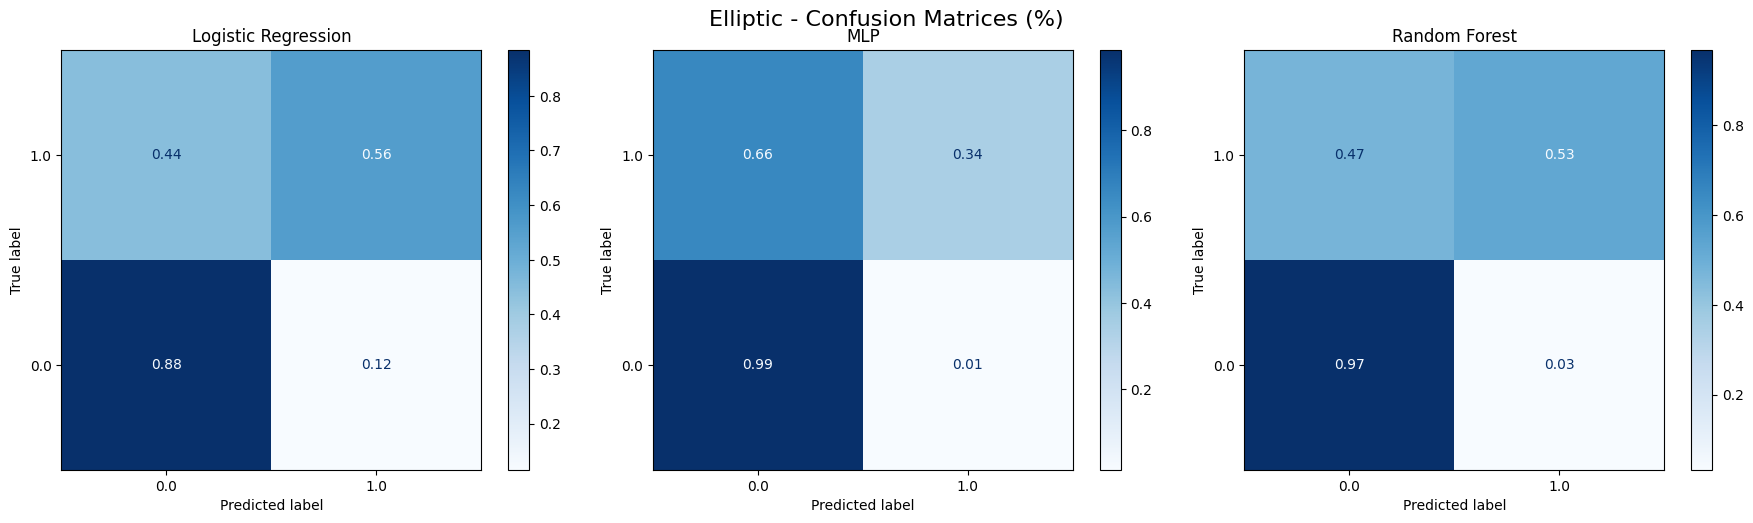


IEEE-CIS - Baseline Models Comparison
Saved ROC curve to /content/drive/MyDrive/GNN_fraud_Project/saved_models_and_results/IEEE-CIS_baseline_ROC.png


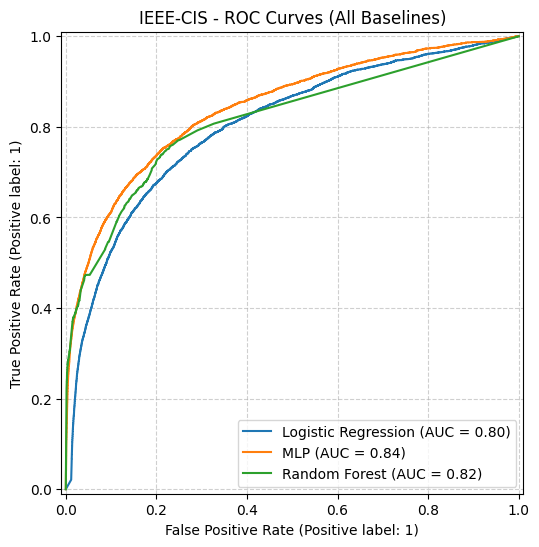

Saved Confusion Matrices to /content/drive/MyDrive/GNN_fraud_Project/saved_models_and_results/IEEE-CIS_baseline_CM.png


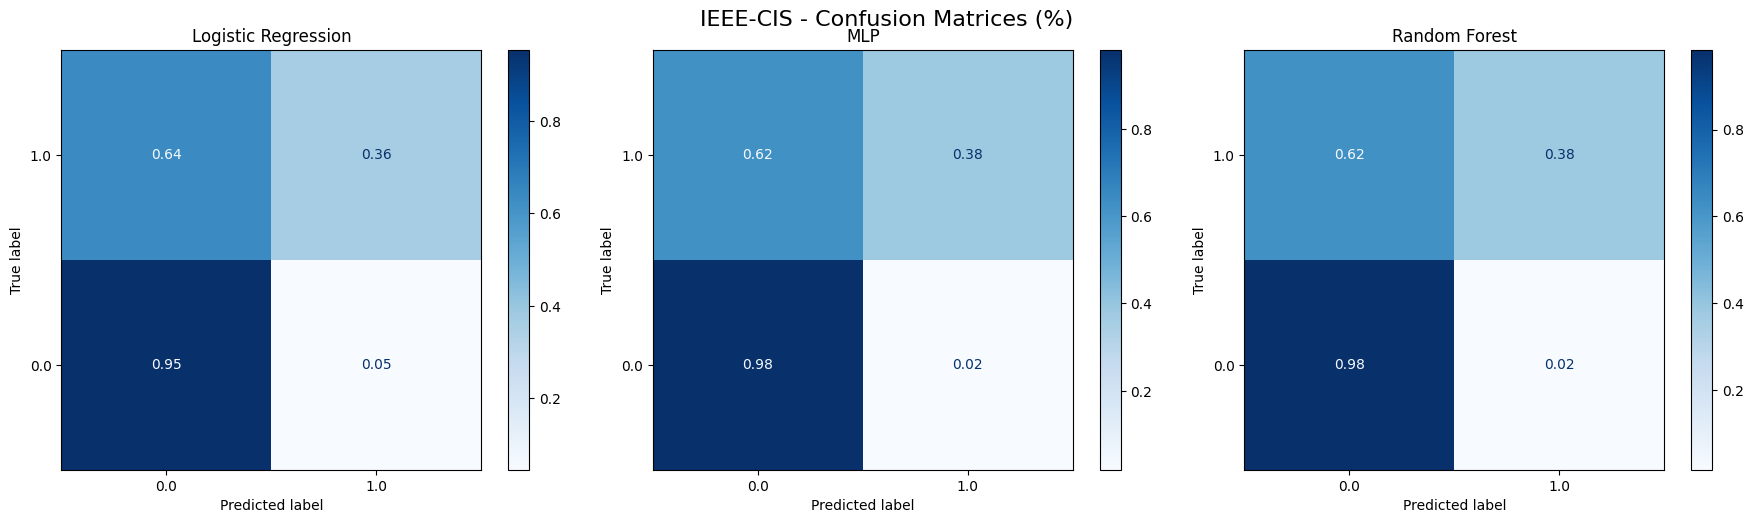

In [16]:
import os
from sklearn.metrics import RocCurveDisplay, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

save_dir = '/content/drive/MyDrive/GNN_fraud_Project/saved_models_and_results'
os.makedirs(save_dir, exist_ok=True)

for dataset, models in all_results.items():
    print(f"\n{'='*60}\n{dataset} - Baseline Models Comparison\n{'='*60}")

    # 1. Overlayed ROC Curves
    fig_roc, ax_roc = plt.subplots(figsize=(8, 6))
    for model_name, (y_test, y_pred, y_prob) in models.items():
        RocCurveDisplay.from_predictions(y_test, y_prob, name=model_name, ax=ax_roc)
    ax_roc.set_title(f"{dataset} - ROC Curves (All Baselines)")
    ax_roc.grid(True, linestyle='--', alpha=0.6)

    roc_path = os.path.join(save_dir, f"{dataset}_baseline_ROC.png")
    plt.savefig(roc_path, bbox_inches='tight')
    print(f"Saved ROC curve to {roc_path}")
    plt.show()

    # 2. Side-by-side Confusion Matrices
    num_models = len(models)
    fig_cm, axes_cm = plt.subplots(1, num_models, figsize=(6 * num_models, 5))
    if num_models == 1:
        axes_cm = [axes_cm]

    for ax, (model_name, (y_test, y_pred, y_prob)) in zip(axes_cm, models.items()):
        disp = ConfusionMatrixDisplay.from_predictions(
            y_test,
            y_pred,
            normalize='true',
            values_format=".2f",
            ax=ax,
            cmap='Blues'
        )
        ax.set_title(f"{model_name}")
        disp.ax_.invert_yaxis()

    fig_cm.suptitle(f"{dataset} - Confusion Matrices (%)", fontsize=16)
    plt.tight_layout()

    cm_path = os.path.join(save_dir, f"{dataset}_baseline_CM.png")
    plt.savefig(cm_path, bbox_inches='tight')
    print(f"Saved Confusion Matrices to {cm_path}")
    plt.show()

In [17]:
import os
import pickle
import pandas as pd
from sklearn.metrics import roc_auc_score, f1_score, precision_score, recall_score

# Create a directory to save models and results in Google Drive
save_dir = '/content/drive/MyDrive/GNN_fraud_Project/saved_models_and_results'
os.makedirs(save_dir, exist_ok=True)

comprehensive_results = {}
summary_data = []

for dataset, models in all_results.items():
    comprehensive_results[dataset] = {}
    for model_name, (y_test, y_pred, y_prob) in models.items():
        # Store results for saving
        comprehensive_results[dataset][model_name] = {
            'y_true': y_test,
            'probs': y_prob,
            'preds': y_pred,
            'config': meta_info[dataset][model_name]
        }

        # Collect metrics for the summary table
        summary_data.append({
            'Dataset': dataset,
            'Model': model_name,
            'AUC': roc_auc_score(y_test, y_prob),
            'F1': f1_score(y_test, y_pred, zero_division=0),
            'Precision': precision_score(y_test, y_pred, zero_division=0),
            'Recall': recall_score(y_test, y_pred, zero_division=0)
        })

# Save all comprehensive baseline results into a single pickle file
results_path = os.path.join(save_dir, 'baseline_comprehensive_results.pkl')
with open(results_path, 'wb') as f:
    pickle.dump(comprehensive_results, f)
print(f"\nSaved comprehensive results (true labels, probabilities, configs) to {results_path}")

# Display Final Summary Table
if summary_data:
    print(f"\n{'='*60}\nFINAL BASELINE PERFORMANCE SUMMARY\n{'='*60}")
    summary_df = pd.DataFrame(summary_data)
    display(summary_df)
else:
    print("No baseline models were found in all_results to summarize.")


Saved comprehensive results (true labels, probabilities, configs) to /content/drive/MyDrive/GNN_fraud_Project/saved_models_and_results/baseline_comprehensive_results.pkl

FINAL BASELINE PERFORMANCE SUMMARY


,Dataset,Model,AUC,F1,Precision,Recall
0,PaySim,Logistic Regression,0.888662,0.521754,0.982445,0.355195
1,PaySim,MLP,0.872917,0.609788,0.996269,0.439351
2,PaySim,Random Forest,0.994344,0.392666,0.252629,0.881053
3,Elliptic,Logistic Regression,0.840864,0.299204,0.204669,0.556025
4,Elliptic,MLP,0.838084,0.431635,0.589744,0.340381
5,Elliptic,Random Forest,0.823252,0.493583,0.462963,0.528541
6,IEEE-CIS,Logistic Regression,0.803648,0.274809,0.221024,0.363189
7,IEEE-CIS,MLP,0.843439,0.395109,0.414193,0.377707
8,IEEE-CIS,Random Forest,0.816087,0.413681,0.459046,0.376476


Across the three fraud detection datasets (PaySim, Elliptic, and IEEE-CIS), the baseline models demonstrate consistent patterns in performance under severe class imbalance. Random Forest generally achieves strong minority-class F1 scores across the datasets, reaching 0.49 on Elliptic and 0.41 on IEEE-CIS, indicating better overall balance between precision and recall compared to linear baselines. However, this comes with trade-offs. On PaySim, while Random Forest achieves an exceptional AUC-ROC (0.99) and high recall (0.88), its precision drops significantly (0.25), resulting in an F1 of 0.39. In contrast, the MLP provides surprisingly strong precision (0.99) on PaySim, yielding the highest F1 score (0.61) despite a lower recall. Logistic Regression tends to struggle with precision across all datasets, acting as a high-recall baseline but generating many false positives. Overall, the extreme variance between precision and recall across models highlights that AUC-ROC is not sufficient for evaluating fraud detection; AUC-PR and F1 scores are much more informative for assessing models in these highly imbalanced domains.

## High-Level Interpretation & Final Summary

#### Class Imbalance and Fraud Detection Performance
Across all three datasets, the primary challenge remains the severe class imbalance. While high AUC-ROC scores (often >0.80) suggest strong overall ranking ability, the more specialized metrics for the **Fraud class** (Class 1) reveal a more nuanced story:

* **PaySim:** This dataset showed varied behaviors across models. **MLP** achieved the highest Fraud F1-score (0.61) due to near-perfect precision (~0.99) but moderate recall (0.44). Meanwhile, **Random Forest** achieved an exceptional AUC-ROC of 0.99 and a high recall of 0.88, but suffered from low precision (0.25), leading to a lower F1 score.
* **Elliptic:** This dataset demonstrated the best balance in identifying fraudulent transactions. **Random Forest** (F1: 0.49) outperformed both the **MLP** (F1: 0.43) and Logistic Regression (F1: 0.30), achieving a well-balanced recall of 0.53 and precision of 0.46 for fraud cases.
* **IEEE-CIS:** This remains the most difficult domain for fraud identification. **Random Forest** (F1: 0.41) and **MLP** (F1: 0.39) provided a more conservative but balanced approach, while **Logistic Regression** produced a very high number of false positives (Precision: 0.22, F1: 0.27).

#### Comparative Model Insights
* **Logistic Regression:** Acts as a naive baseline that struggles significantly with precision in complex datasets, leading to high false-positive rates for fraud.
* **Random Forest (XGBoost):** Consistently produced robust results across all datasets, demonstrating a strong ability to find patterns in imbalanced tabular data, though it can over-predict the minority class (as seen in PaySim) if thresholding is not perfectly calibrated.
* **Multilayer Perceptron (MLP):** Showed strong non-linear learning potential, unexpectedly outperforming Random Forest on PaySim's F1 score by being extremely precise, and sitting comfortably between the linear baseline and the ensemble method on Elliptic and IEEE-CIS.

#### Conclusion
The performance ceiling observed in the IEEE-CIS dataset and the trade-offs between precision and recall across all tabular models indicate that row-independent features have reached their limit. The next step is to leverage Graph Neural Networks (GNNs) to incorporate the relational and structural context between transactions, which we expect will significantly improve the precision-recall balance for detecting rare fraud events.